# Convolutional Neural Networks (CNNs)

## 1. Motivation

Images contain **spatial structure**:

- Nearby pixels are correlated
- Patterns are **local**
- Patterns can appear **anywhere in the image**

Fully connected networks ignore this structure and require a very large number of parameters.

Example:

For an image:

$$
64 \times 64 \times 3 = 12288 \text{ inputs}
$$

First dense layer with 100 neurons:

$$
12288 \times 100 = 1,228,800 \text{ parameters}
$$

CNNs solve this by introducing:

1. **Local connectivity**
2. **Weight sharing**

---

# 2. Convolution Layer

A convolution layer applies a **small filter** across the image.

Input:

$$
X \in \mathbb{R}^{H \times W}
$$

Filter:

$$
W \in \mathbb{R}^{k \times k}
$$

Output:

$$
Y
$$

The convolution operation:

$$
Y(i,j) =
\sum_{u=1}^{k}
\sum_{v=1}^{k}
W(u,v)X(i+u,j+v)
$$

---

# 3. Dot Product Interpretation

The convolution can be written as a **dot product**.

Flatten the patch:

$$
x_{patch} \in \mathbb{R}^{k^2}
$$

Flatten the filter:

$$
w \in \mathbb{R}^{k^2}
$$

Then:

$$
y = \langle w, x_{patch} \rangle
$$

---

# 4. Geometric Interpretation

Each **patch of the image** is a vector in:

$$
\mathbb{R}^{k^2}
$$

The filter represents a **direction in this space**.

The convolution computes:

$$
y = \langle w, x_{patch} \rangle
$$

Interpretation:

- Large value → patch aligned with the filter
- Small value → patch different from the filter

Therefore:

> A convolution filter is a **pattern detector**.

Examples:

- edges
- corners
- textures

---

# 5. Multiple Filters → Feature Maps

CNNs apply **multiple filters**.

If we use $K$ filters:

$$
W_1, W_2, ..., W_K
$$

Each produces a feature map:

$$
Y_k(i,j) =
\langle W_k, X_{patch} \rangle + b_k
$$

After activation:

$$
Y_k(i,j) =
ReLU(\langle W_k, X_{patch} \rangle + b_k)
$$

Output tensor:

$$
Y \in \mathbb{R}^{H' \times W' \times K}
$$

Each channel represents **a different learned pattern detector**.

---

# 6. Activation Function

Most CNNs use **ReLU**:

$$
ReLU(x) = \max(0,x)
$$

Interpretation:

- negative responses removed
- only **strong pattern matches remain**

---

## 7. Pooling

Pooling reduces the **spatial resolution** of feature maps.

Example:

Input feature map: 32x32
After max pooling with a $2 \times 2$ window: 16x16


The operation is applied independently to each channel.

---

### Max Pooling

The most common pooling operation is **Max Pooling**.

For a pooling window of size $2 \times 2$:

$$
Y(i,j) =
\max_{u,v}
X(2i+u, 2j+v)
$$

Example region:
1   5
2   3

Max pooling output: 5


The largest activation inside the region is preserved.

---

### Intuition

Pooling performs **spatial abstraction**.

Small changes in the position of patterns should not drastically change the network output.

Example:
edge detected at pixel (10,10)
edge detected at pixel (11,10)


These represent essentially the **same pattern**, just slightly shifted.

Pooling helps the network become **robust to small translations**.

---

### Geometric Interpretation

Pooling selects the **strongest projection value** in a neighborhood.

Recall that a convolution filter computes:

$$
y = \langle w, x_{patch} \rangle
$$

Pooling then keeps the **largest response** among nearby activations.

Interpretation:

> If the pattern appears anywhere inside that region, the detector remains active.

---

### Effect of Pooling

Pooling produces three main effects:

#### 1. Spatial Downsampling

Feature maps become smaller: 32×32 → 16×16


This reduces computation.

---

#### 2. Translation Tolerance

Small shifts in the input image produce similar feature maps.

---

#### 3. Larger Effective Receptive Fields

After pooling, deeper neurons depend on **larger regions of the image**.

This allows deeper layers to detect **larger structures**.

---

## Example: filter effects throw layers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import ArrayLike

rng = np.random.default_rng(42)

def create_img(w, h):
    img = np.zeros((w, h), dtype=np.int16)

    for i in range(img.shape[0]):    
        for j in range(img.shape[1]):
            if i > 0 and i < img.shape[0] - 1 and j > 0 and j < img.shape[1] - 1:
                img[i, j] = 1

    return img

def apply_filter(img, kernel):
    k = kernel.shape[0]
    pad = k // 2

    img_padded = np.pad(img, pad, mode="constant")
    h, w = img.shape
    output = np.zeros((h, w))

    bias = rng.standard_normal()
            
    for i in range(h):
        for j in range(w):
            patch = img_padded[i:i+k, j:j+k]
            output[i, j] = np.sum(patch * kernel) + bias

    return output

def sigmoid(z: ArrayLike):
    return 1 / (1 + np.exp(-z))


In [2]:
img = create_img(10, 10)
img

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=int16)

In [3]:
filter_edges_h = np.zeros((3, 3))
filter_edges_h[:, 0] = 1
filter_edges_h[:, 2] = -1

filter_edges_v = np.zeros((3, 3))
filter_edges_v[0, :] = 1
filter_edges_v[2, :] = -1

filter_blur = np.ones((3, 3)) / 5

filter_sharpening = np.full((3, 3), -1/(3**2 - 1))
c = 3 // 2
filter_sharpening[c, c] = 2

In [4]:
z1 = apply_filter(img, filter_blur)
layer_1 = sigmoid(z1)
z2 = apply_filter(layer_1, filter_sharpening)
layer_2 = sigmoid(z2)

z3= apply_filter(layer_2, filter_edges_h)
z4= apply_filter(layer_2, filter_edges_v)
output = z3 @ z4
output

array([[ 8.66009857,  9.47232596,  9.44542809,  9.47501905,  9.46494792,
         9.46494792,  9.47501905,  9.44542809,  9.47232596,  8.66009857],
       [ 9.47232596, 10.69657482, 10.65610618, 10.70076802, 10.68553916,
        10.68553916, 10.70076802, 10.65610618, 10.69657482,  9.47232596],
       [ 9.44542809, 10.65610618, 10.61615967, 10.66034333, 10.64525827,
        10.64525827, 10.66034333, 10.61615967, 10.65610618,  9.44542809],
       [ 9.47501905, 10.70076802, 10.66034333, 10.70513004, 10.68983203,
        10.68983203, 10.70513004, 10.66034333, 10.70076802,  9.47501905],
       [ 9.46494792, 10.68553916, 10.64525827, 10.68983203, 10.67462161,
        10.67462161, 10.68983203, 10.64525827, 10.68553916,  9.46494792],
       [ 9.46494792, 10.68553916, 10.64525827, 10.68983203, 10.67462161,
        10.67462161, 10.68983203, 10.64525827, 10.68553916,  9.46494792],
       [ 9.47501905, 10.70076802, 10.66034333, 10.70513004, 10.68983203,
        10.68983203, 10.70513004, 10.66034333

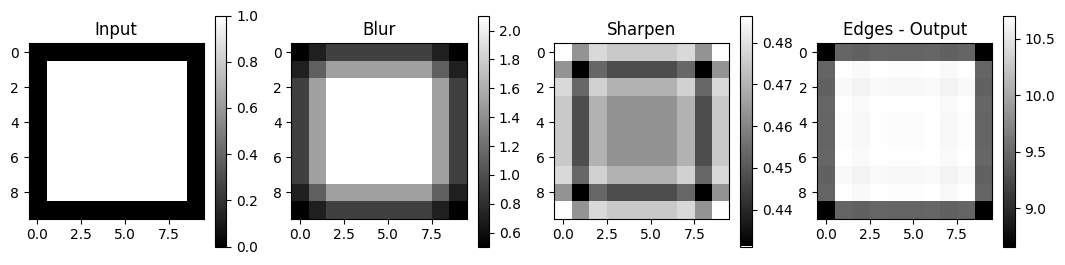

In [5]:
plt.figure(figsize=(13,3))

plt.subplot(1,4,1)
plt.title("Input")
plt.imshow(img, cmap="gray")
plt.colorbar()

plt.subplot(1,4,2)
plt.title("Blur")
plt.imshow(z1, cmap="gray")
plt.colorbar()

plt.subplot(1,4,3)
plt.title("Sharpen")
plt.imshow(layer_2, cmap="gray")
plt.colorbar()

plt.subplot(1,4,4)
plt.title("Edges - Output")
plt.imshow(output, cmap="gray")
plt.colorbar()

plt.show()

## Example: Classify Images Containing Three Geometric Shapes

In this experiment we construct and train a **Convolutional Neural Network (CNN)** to classify synthetic grayscale images containing one of three geometric shapes: **square, circle, or triangle**. The images are generated programmatically and have a resolution of **32×32 pixels** with a single channel.

Synthetic datasets are useful for studying neural networks because they allow us to **control the data generation process**, isolate specific visual patterns, and better understand how convolutional networks learn representations such as edges, corners, and curved boundaries.

To make the task more realistic and prevent the model from simply memorizing pixel patterns, we introduce two types of **data augmentation** during dataset generation:

- **Random rotation:** Shapes are rotated by random angles so that the network must learn **orientation-invariant features** rather than fixed spatial templates.
- **Additive noise:** Random noise is added to the images, forcing the model to learn **robust visual features** rather than relying on perfectly clean edges.

These transformations encourage the CNN to learn meaningful geometric features such as **edges, diagonals, and curvature**, which are shared across different shapes.

---

### Motivation

The goal of this experiment is twofold:

1. **Demonstrate how convolutional neural networks learn geometric features** from raw pixel data.
2. **Illustrate the mechanics of a residual architecture (ResNet)** in a simple and interpretable setting.

Residual networks introduce **skip connections** that allow the network to learn a residual mapping of the form:

$$
H(x) = F(x) + x
$$

Instead of learning a direct transformation \(H(x)\), the network learns the residual function \(F(x)\), which often makes optimization easier and improves gradient propagation in deeper networks.

---

### Proposed Architecture

The model follows a simplified **ResNet-style architecture** consisting of a convolutional feature extractor, a residual connection, and a lightweight classifier.

input (1×32×32) 

conv3×3 <br /> 
batchnorm <br />
ReLU 

conv3×3 <br /> 
batchnorm <br /> 
\+ <br /> 
skip connection<br /> 
ReLU 


maxpool 2×2 <br /> 
global average pooling <br /> 
linear → 3

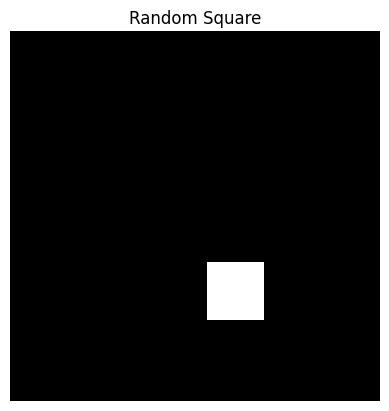

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
torch.manual_seed(42)

g = torch.Generator()
g.manual_seed(42)

def make_rnd_square(rng):
    img = np.zeros((32,32), dtype=np.float32)

    k = rng.integers(low=5, high=13)
    x = rng.integers(0, 32-k)
    y = rng.integers(0, 32-k)
    img[x : x+k, y : y+k] = 1

    return img

def add_noise(rng, img):
    positions = [(rng.integers(0, 32), rng.integers(0, 32)) for i in range(30)]

    for p in positions:
        img[p[0], p[1]] = 1
    
    return img

squares = np.array([make_rnd_square(rng) for i in range(1000)])

def move(rng, img):
    aux = rng.integers(low=0, high=6)
    
    if aux == 0:
        img = img.T
    elif aux == 1:
        img = img.T * -1
    elif aux == 3:
        img = np.flip(img)
    elif aux == 4:
        img = np.rot90(img)
    elif aux == 5:
        img = np.rot90(img.T)
    
    return img

plt.imshow(squares[0], cmap="gray")
plt.title("Random Square")
plt.axis("off")
plt.show()

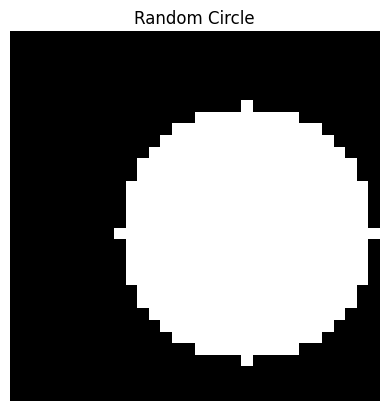

In [7]:
def draw_rnd_circle(rng):

    img = np.zeros((32, 32), dtype=np.float32)
    r = rng.integers(low=5, high=13)
    cx = rng.integers(r, 32-r)
    cy = rng.integers(r, 32-r)

    for i in range(32):
        for j in range(32):
            if (i-cx)**2 + (j-cy)**2 <= r**2:
                img[i,j] = 1

    return img


circles = np.array([draw_rnd_circle(rng) for i in range(1000)])

plt.imshow(circles[0], cmap="gray")
plt.title("Random Circle")
plt.axis("off")
plt.show()

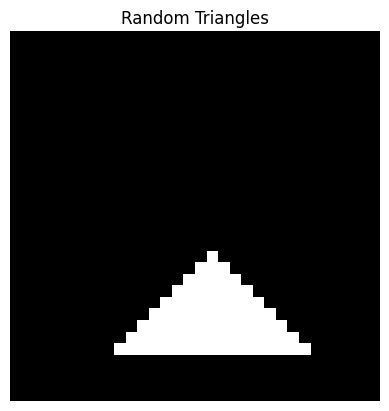

In [8]:

def draw_rnd_isosceles_triangle(rng):

    img = np.zeros((32, 32), dtype=np.float32)
    k = rng.integers(5, 12)

    top_x = rng.integers(0, 32 - k)
    center_y = rng.integers(k, 32 - k)

    for d in range(k):
        row = top_x + d
        left = center_y - d
        right = center_y + d

        img[row, left:right+1] = 1
    
    return img

triangles = np.array([draw_rnd_isosceles_triangle(rng) for i in range(1000)])

plt.imshow(triangles[0], cmap="gray")
plt.title("Random Triangles")
plt.axis("off")
plt.show()

In [9]:
x = np.vstack((squares, circles, triangles))
x = np.array([add_noise(rng, x[i]) for i in range(len(x))])

idxs = rng.integers(low=0, high=3000, size=1500)

for idx in idxs:
    x [idx]= move(rng, x[idx])

y = np.hstack(([0.] * len(squares), [1.] * len(circles), [2.] * len(triangles))).reshape(-1, 1)

permutation = [int(i) for i in rng.permutation(len(x))]
x_permuted = x[permutation]
y_permuted = y[permutation] 

# Adding a color channel
x_permuted = x_permuted[:, None, :, :]

X_torch = torch.tensor(x_permuted, dtype=torch.float32)
y_torch = torch.tensor(y_permuted, dtype=torch.float32)

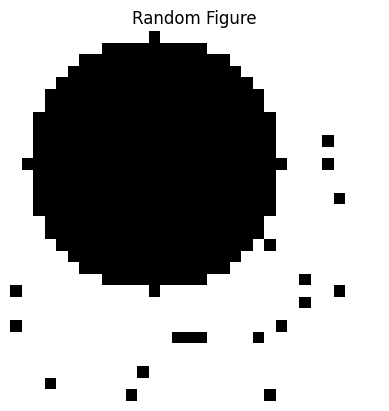

In [10]:
plt.imshow(x[idxs[0]], cmap="gray")
plt.title("Random Figure")
plt.axis("off")
plt.show()

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        if in_channels != out_channels:
            self.projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.projection = nn.Identity()

    def forward(self, x):

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + self.projection(x)
        out = F.relu(out)

        return out
        
        

In [12]:
class SimpleResNet(nn.Module):

    def __init__(self, channels=8, num_classes=3):
        super().__init__()

        self.conv_in = nn.Conv2d(1, channels, kernel_size=3, padding=1)
        self.bn_in = nn.BatchNorm2d(channels)

        self.res_block = ResidualBlock(channels, channels)
        self.pool = nn.MaxPool2d(2)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(channels, num_classes)

    def forward(self, x):

        x = self.conv_in(x)
        x = self.bn_in(x)
        x = F.relu(x)

        x = self.res_block(x)
        x = self.pool(x)
        x = self.global_pool(x)

        x = torch.flatten(x, 1)
        x = self.fc(x)

        if self.training == False:
             x = F.softmax(x, dim=1)

        return x

In [13]:
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

dataset = TensorDataset(X_torch, y_torch)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    generator=g
)

model = SimpleResNet(channels=8)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()

for epoch in range(30):
    for X_batch, y_batch in loader:

        optimizer.zero_grad()
        outputs = model(X_batch)

        y_batch = y_batch.squeeze().long()
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

    if epoch % 5 == 0 or epoch == 29:
        print("epoch:", epoch, "loss:", loss.item())

epoch: 0 loss: 0.9683705568313599
epoch: 5 loss: 0.6119852066040039
epoch: 10 loss: 0.3411809504032135
epoch: 15 loss: 0.1938011646270752
epoch: 20 loss: 0.09548675268888474
epoch: 25 loss: 0.07707194983959198
epoch: 29 loss: 0.037796251475811005


In [16]:
squares = np.array([make_rnd_square(rng) for i in range(500)])
circles = np.array([draw_rnd_circle(rng) for i in range(500)])
triangles = np.array([draw_rnd_isosceles_triangle(rng) for i in range(500)])

x = np.vstack((squares, circles, triangles))
x = np.array([add_noise(rng, x[i]) for i in range(len(x))])

idxs = rng.integers(low=0, high=len(x), size=1500)

for idx in idxs:
    x [idx]= move(rng, x[idx])

y = np.hstack(([0.] * len(squares), [1.] * len(circles), [2.] * len(triangles))).reshape(-1, 1)

permutation = [int(i) for i in rng.permutation(len(x))]
x_permuted = x[permutation]
y_permuted = y[permutation] 

# Adding a color channel
x_permuted = x_permuted[:, None, :, :]

torch.manual_seed(42)
X_torch = torch.tensor(x_permuted, dtype=torch.float32)
y_torch = torch.tensor(y_permuted, dtype=torch.float32)

In [17]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model.eval()

with torch.no_grad():
    outputs = model(X_torch)
    preds = outputs.argmax(dim=1)

y_true = y_torch.cpu().numpy()
y_pred = preds.cpu().numpy()

print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nPrecision:", precision_score(y_true, y_pred, average=None))
print("Recall:", recall_score(y_true, y_pred, average=None))
print("F1-score:", f1_score(y_true, y_pred, average=None))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nFull Classification Report:")
print(classification_report(y_true, y_pred))

Accuracy: 0.9913333333333333

Precision: [0.98231827 0.99201597 1.        ]
Recall: [1.    0.994 0.98 ]
F1-score: [0.99108028 0.99300699 0.98989899]

Confusion Matrix:
[[500   0   0]
 [  3 497   0]
 [  6   4 490]]

Full Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99       500
         1.0       0.99      0.99      0.99       500
         2.0       1.00      0.98      0.99       500

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500

